LAB -9 DHANUSH.V 1RUA24SCS0031

Lab 9 Implement a simple reinforcement learning agent

Final Q-table:
 [[-0.10090685  3.01588794]
 [-0.84099483  4.540938  ]
 [ 1.20200052  6.18757218]
 [ 0.54484871  7.99815423]
 [ 3.02520249  9.99973439]
 [ 0.          0.        ]]


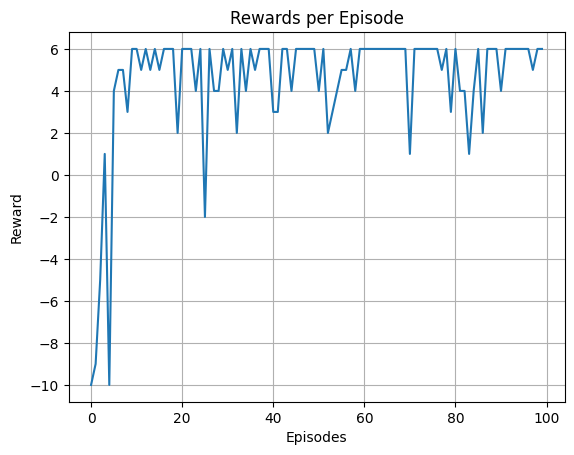

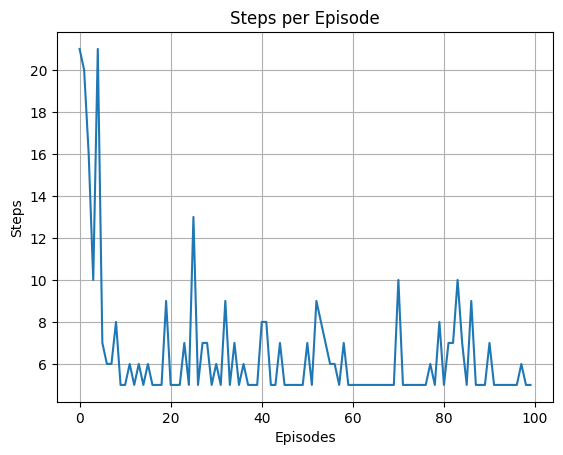

In [3]:
import numpy as np
import matplotlib.pyplot as plt

n_states = 6
actions = [0, 1]  
goal_state = 5


Q = np.zeros((n_states, len(actions)))


alpha = 0.1
gamma = 0.9
epsilon = 0.2
episodes = 100

rewards_per_episode = []
steps_per_episode = []


for ep in range(episodes):
    state = 0
    total_reward = 0
    steps = 0

    while state != goal_state:

        
        if np.random.rand() < epsilon:
            action = np.random.choice(actions)
        else:
            action = np.argmax(Q[state])

       
        if action == 1:
            next_state = min(state + 1, n_states - 1)
        else:
            next_state = max(state - 1, 0)

       
        if next_state == goal_state:
            reward = 10
        else:
            reward = -1

        
        Q[state, action] = Q[state, action] + alpha * (
            reward + gamma * np.max(Q[next_state]) - Q[state, action]
        )

        state = next_state
        total_reward += reward
        steps += 1

    rewards_per_episode.append(total_reward)
    steps_per_episode.append(steps)


print("Final Q-table:\n", Q)


plt.figure()
plt.plot(rewards_per_episode)
plt.title("Rewards per Episode")
plt.xlabel("Episodes")
plt.ylabel("Reward")
plt.grid()
plt.show()


plt.figure()
plt.plot(steps_per_episode)
plt.title("Steps per Episode")
plt.xlabel("Episodes")
plt.ylabel("Steps")
plt.grid()
plt.show()